In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

In [2]:
X_train_sm = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train_sm = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print(f"X_train: {X_train_sm.shape}")
print(f"X_test: {X_test.shape}")


X_train: (454902, 30)
X_test: (56962, 30)


In [3]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    max_iter=50,
    random_state=42,
    verbose=False
)

model.fit(X_train_sm, y_train_sm)
print("Model istreniran!")

Model istreniran!


In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



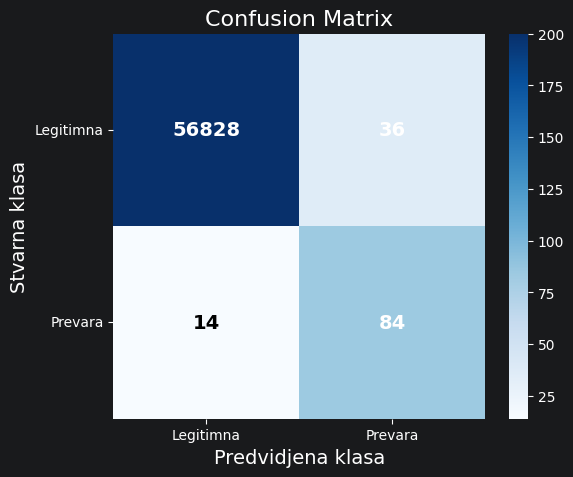

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

sb.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=['Legitimna', 'Prevara'],
    yticklabels=['Legitimna', 'Prevara'],
    cbar=True,
    vmax=200
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j + 0.5,
            i + 0.5,
            str(cm[i, j]),
            ha='center',
            va='center',
            color='white' if cm[i, j] > 30 else 'black',
            fontsize=14,
            fontweight='bold'
        )

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Stvarna klasa', fontsize=14)
plt.xlabel('Predvidjena klasa', fontsize=14)
plt.yticks(rotation=0)
plt.show()

AUC-ROC: 0.964


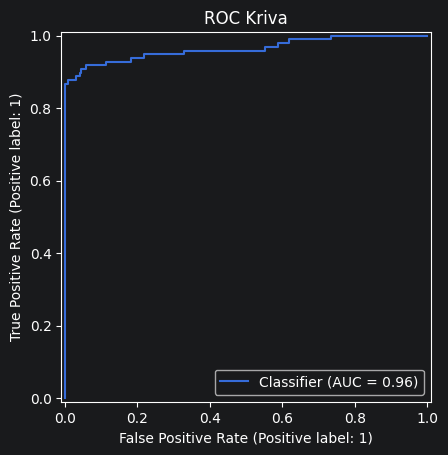

In [6]:
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title('ROC Kriva')
plt.show()

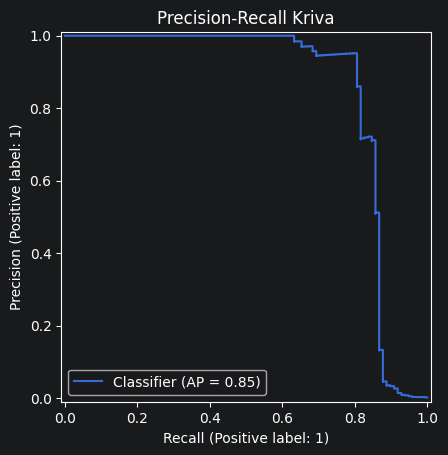

In [7]:
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title('Precision-Recall Kriva')
plt.show()

In [8]:
X_test_reset = X_test.reset_index(drop=True)

pogresno = X_test_reset[(y_test == 1) & (y_pred == 0)]
print(f"Propustenih prevara (False Negative): {len(pogresno)}")
print(f"Laznih uzbuna (False Positive): {((y_test == 0) & (y_pred == 1)).sum()}")
print(f"\nIznosi propustenih prevara:")
print(pogresno['Amount'].describe())

Propustenih prevara (False Negative): 14
Laznih uzbuna (False Positive): 36

Iznosi propustenih prevara:
count    14.000000
mean      0.176694
std       0.940069
min      -0.349231
25%      -0.345393
50%      -0.336677
75%      -0.029404
max       2.185955
Name: Amount, dtype: float64
